# 03. Meta-Learners: S, T, X, R, and DR

Meta-learners are recipes for turning ordinary supervised learning models into CATE estimators. Instead of inventing a new causal model from scratch, a meta-learner says: fit this outcome model, this propensity model, this pseudo-outcome, or this residualized regression, then combine the pieces into an estimate of $\tau(x)$.

This notebook builds the main meta-learners from first principles using scikit-learn. The goal is not to replace libraries such as EconML or causalml. The goal is to understand what those libraries are doing and why different meta-learners behave differently.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain what makes S-, T-, X-, R-, and DR-learners different.
- Identify the nuisance functions used in CATE estimation.
- Understand why meta-learners can disagree even when they use the same base learner family.
- Implement simple versions of common meta-learners with scikit-learn.
- Compare CATE estimators using simulation ground truth, policy value, and bucket-level validation.
- Choose a reasonable first meta-learner for an industry problem based on treatment imbalance, confounding risk, and expected heterogeneity.

In [1]:
import warnings

import graphviz
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, roc_auc_score
from sklearn.model_selection import KFold, train_test_split

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", "{:.3f}".format)

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_dag(edges, title=None, node_colors=None, rankdir="LR"):
    graph = graphviz.Digraph(format="svg")
    graph.attr(rankdir=rankdir, bgcolor="white", pad="0.2")
    graph.attr("node", shape="box", style="rounded,filled", color="#334155", fontname="Helvetica")
    graph.attr("edge", color="#475569", arrowsize="0.8")

    node_colors = node_colors or {}
    nodes = sorted({node for edge in edges for node in edge[:2]})
    for node in nodes:
        graph.node(node, fillcolor=node_colors.get(node, "#eef2ff"))

    for edge in edges:
        if len(edge) == 2:
            graph.edge(edge[0], edge[1])
        else:
            graph.edge(edge[0], edge[1], label=edge[2])

    if title:
        graph.attr(label=title, labelloc="t", fontsize="18", fontname="Helvetica-Bold")
    return graph


def reg_model(seed, min_samples_leaf=40):
    return RandomForestRegressor(
        n_estimators=150,
        min_samples_leaf=min_samples_leaf,
        random_state=seed,
        n_jobs=-1,
    )


def cls_model(seed, min_samples_leaf=40):
    return RandomForestClassifier(
        n_estimators=150,
        min_samples_leaf=min_samples_leaf,
        random_state=seed,
        n_jobs=-1,
    )


def simulate_customer_success_data(n=12_000, seed=5303):
    rng = np.random.default_rng(seed)

    risk_score = rng.beta(2.1, 2.6, n)
    usage_z = rng.normal(0, 1, n)
    log_account_value = rng.normal(4.35, 0.55, n)
    account_value = np.exp(log_account_value)
    tenure_months = rng.gamma(2.3, 9.0, n)
    enterprise_plan = rng.binomial(1, sigmoid(-0.45 + 0.75 * (log_account_value - 4.35) + 0.35 * risk_score), n)
    support_tickets = rng.poisson(np.clip(0.7 + 2.8 * risk_score - 0.3 * usage_z + 0.5 * enterprise_plan, 0.1, None))
    discount_sensitivity = rng.beta(2.4, 2.2, n)
    region = rng.choice(["North", "South", "West"], size=n, p=[0.36, 0.31, 0.33])
    region_west = (region == "West").astype(float)
    region_south = (region == "South").astype(float)

    mu0 = (
        70
        + 0.16 * account_value
        + 7.0 * usage_z
        - 13.0 * risk_score
        + 5.0 * enterprise_plan
        + 0.10 * tenure_months
        - 1.8 * support_tickets
        + 2.5 * region_west
        - 1.5 * region_south
        + 3.0 * np.sin(usage_z)
    )

    true_cate = (
        -3.0
        + 14.0 * risk_score
        + 3.0 * enterprise_plan
        + 3.5 * discount_sensitivity
        + 2.0 * (support_tickets >= 4).astype(float)
        - 3.8 * (usage_z > 1.2).astype(float)
        - 2.0 * (tenure_months < 6).astype(float)
        + 1.5 * region_west
    )

    propensity_logit = (
        -0.15
        + 1.25 * risk_score
        + 0.55 * enterprise_plan
        + 0.38 * (log_account_value - 4.35)
        - 0.45 * usage_z
        + 0.25 * support_tickets
        + 0.15 * discount_sensitivity
        + 0.25 * region_south
    )
    propensity = np.clip(sigmoid(propensity_logit), 0.06, 0.94)

    treatment = rng.binomial(1, propensity, n)
    outcome = mu0 + treatment * true_cate + rng.normal(0, 7.0, n)

    return pd.DataFrame(
        {
            "account_id": np.arange(1, n + 1),
            "risk_score": risk_score,
            "usage_z": usage_z,
            "log_account_value": log_account_value,
            "account_value": account_value,
            "tenure_months": tenure_months,
            "enterprise_plan": enterprise_plan,
            "support_tickets": support_tickets,
            "discount_sensitivity": discount_sensitivity,
            "region": region,
            "region_west": region_west,
            "region_south": region_south,
            "propensity": propensity,
            "treatment": treatment,
            "outcome": outcome,
            "mu0": mu0,
            "true_cate": true_cate,
        }
    )


def top_fraction_mask(frame, score_col, fraction=0.20, largest=True):
    n_select = max(1, int(np.floor(fraction * len(frame))))
    selected_index = frame[score_col].sort_values(ascending=not largest).head(n_select).index
    mask = pd.Series(False, index=frame.index)
    mask.loc[selected_index] = True
    return mask


def cate_metrics(frame, score_col, label, contact_fraction=0.20, margin=1.0, contact_cost=0.0):
    score = frame[score_col].to_numpy()
    truth = frame["true_cate"].to_numpy()
    rmse = np.sqrt(mean_squared_error(truth, score))
    corr = np.corrcoef(score, truth)[0, 1]
    selected = top_fraction_mask(frame, score_col, fraction=contact_fraction)
    targeted = frame.loc[selected]
    return {
        "learner": label,
        "cate_rmse": rmse,
        "cate_correlation": corr,
        "mean_predicted_cate": frame[score_col].mean(),
        "true_ate_in_test": frame["true_cate"].mean(),
        "true_cate_top20": targeted["true_cate"].mean(),
        "share_negative_top20": (targeted["true_cate"] < 0).mean(),
        "net_value_per_account_top20": contact_fraction * (targeted["true_cate"].mean() * margin - contact_cost),
    }


def decile_summary(frame, score_col, dr_score_col=None):
    work = frame.sort_values(score_col, ascending=False).reset_index(drop=True).copy()
    work["score_decile"] = pd.qcut(
        np.arange(len(work)),
        q=10,
        labels=[f"D{i} highest" if i == 1 else f"D{i}" for i in range(1, 11)],
    )

    rows = []
    for decile, group in work.groupby("score_decile", observed=True):
        treated = group.loc[group["treatment"] == 1, "outcome"]
        control = group.loc[group["treatment"] == 0, "outcome"]
        row = {
            "decile": str(decile),
            "n": len(group),
            "treatment_share": group["treatment"].mean(),
            "naive_gap": treated.mean() - control.mean(),
            "true_cate_mean": group["true_cate"].mean(),
            "predicted_cate_mean": group[score_col].mean(),
        }
        if dr_score_col is not None:
            row["dr_pseudo_outcome_mean"] = group[dr_score_col].mean()
        rows.append(row)
    return pd.DataFrame(rows)

## 1. What Is a Meta-Learner?

A meta-learner is not a single model. It is a procedure for organizing one or more ordinary predictive models around a causal estimand.

For binary treatment $W \in \{0,1\}$, the target is usually the CATE:

$$
\tau(x) = E[Y(1) - Y(0) \mid X=x]
$$

A meta-learner may estimate:

$$
\mu_1(x) = E[Y \mid W=1, X=x]
$$

$$
\mu_0(x) = E[Y \mid W=0, X=x]
$$

and then take a difference. Or it may estimate nuisance functions and build a pseudo-outcome whose conditional expectation is $\tau(x)$.

Kunzel et al. (2019) popularized the S-, T-, and X-learner terminology for CATE estimation with machine learning. Nie and Wager (2020) developed the R-learner, which uses residualization to separate treatment-effect estimation from nuisance estimation. Kennedy (2023) studies doubly robust CATE estimation based on augmented inverse-probability ideas.

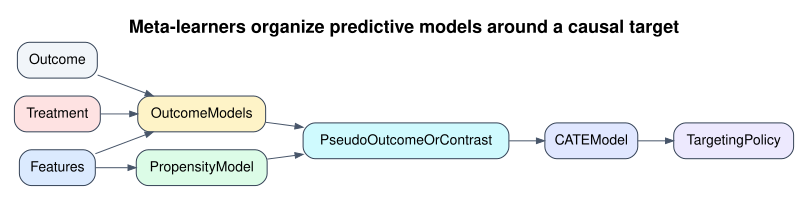

In [3]:
make_dag(
    edges=[
        ("Features", "OutcomeModels"),
        ("Features", "PropensityModel"),
        ("Treatment", "OutcomeModels"),
        ("Outcome", "OutcomeModels"),
        ("OutcomeModels", "PseudoOutcomeOrContrast"),
        ("PropensityModel", "PseudoOutcomeOrContrast"),
        ("PseudoOutcomeOrContrast", "CATEModel"),
        ("CATEModel", "TargetingPolicy"),
    ],
    title="Meta-learners organize predictive models around a causal target",
    node_colors={
        "Features": "#dbeafe",
        "Treatment": "#fee2e2",
        "Outcome": "#f1f5f9",
        "OutcomeModels": "#fef3c7",
        "PropensityModel": "#dcfce7",
        "PseudoOutcomeOrContrast": "#cffafe",
        "CATEModel": "#e0e7ff",
        "TargetingPolicy": "#ede9fe",
    },
)

The causal assumptions are the same assumptions from earlier observational-adjustment notebooks:

- Consistency: the observed outcome equals the potential outcome under the treatment actually received.
- Conditional exchangeability: after conditioning on pre-treatment features $X$, treatment assignment is as good as random.
- Positivity or overlap: every relevant feature profile has some chance of receiving treatment and control.

Meta-learners do not remove the need for these assumptions. They only give us flexible ways to estimate the functions implied by the assumptions.

## 2. Running Example: Customer Success Intervention

Suppose a SaaS company offers an intensive customer-success intervention. The intervention includes an onboarding review, retention consultation, and custom usage recommendations. The outcome is next-quarter gross margin.

This is not a clean randomized experiment. Account managers tend to assign the intervention to accounts that look risky, valuable, or complicated. All assignment drivers in this simulation are observed, so adjustment is possible. In real life, unobserved assignment drivers would be a serious threat.

The intervention has heterogeneous effects:

- High-risk accounts benefit because the intervention prevents churn.
- Enterprise accounts benefit more because customized support has more room to create value.
- Already-high-usage accounts benefit less because they are closer to saturation.
- Some very new accounts are not ready for the intervention yet.

In [4]:
df = simulate_customer_success_data()

feature_cols = [
    "risk_score",
    "usage_z",
    "log_account_value",
    "tenure_months",
    "enterprise_plan",
    "support_tickets",
    "discount_sensitivity",
    "region_west",
    "region_south",
]

summary = pd.DataFrame(
    {
        "quantity": [
            "Accounts",
            "Treatment share",
            "Mean propensity",
            "Observed outcome mean",
            "True ATE",
            "Share with negative true CATE",
            "Naive treated-control gap",
        ],
        "value": [
            len(df),
            df["treatment"].mean(),
            df["propensity"].mean(),
            df["outcome"].mean(),
            df["true_cate"].mean(),
            (df["true_cate"] < 0).mean(),
            df.loc[df["treatment"] == 1, "outcome"].mean() - df.loc[df["treatment"] == 0, "outcome"].mean(),
        ],
    }
)

display(summary.round(3))
display(df.head())

,quantity,value
0,Accounts,12000.000
1,Treatment share,0.758
2,Mean propensity,0.759
3,Observed outcome mean,84.725
4,True ATE,6.631
5,Share with negative true CATE,0.042
6,Naive treated-control gap,2.651


,account_id,risk_score,usage_z,log_account_value,account_value,tenure_months,enterprise_plan,support_tickets,discount_sensitivity,region,region_west,region_south,propensity,treatment,outcome,mu0,true_cate
0,1,0.593,1.043,4.949,141.012,29.962,0,6,0.631,West,1.000,0.000,0.875,1,95.214,89.437,11.013
1,2,0.242,1.636,3.475,32.305,19.976,1,1,0.787,North,0.000,0.000,0.500,1,90.775,91.667,2.339
2,3,0.245,-2.028,3.084,21.849,14.811,0,4,0.380,South,0.000,1.000,0.869,1,58.328,46.203,3.760
3,4,0.456,-2.827,3.806,44.992,49.803,1,3,0.674,West,1.000,0.000,0.940,1,76.228,57.630,10.244
4,5,0.079,1.189,4.927,137.934,8.847,1,2,0.285,South,0.000,1.000,0.726,1,108.223,102.930,2.109


The treatment share is high because the intervention is preferentially assigned to risky and complex accounts. The naive treated-control gap is not the ATE. It mixes treatment effects with pre-existing differences between treated and untreated accounts.

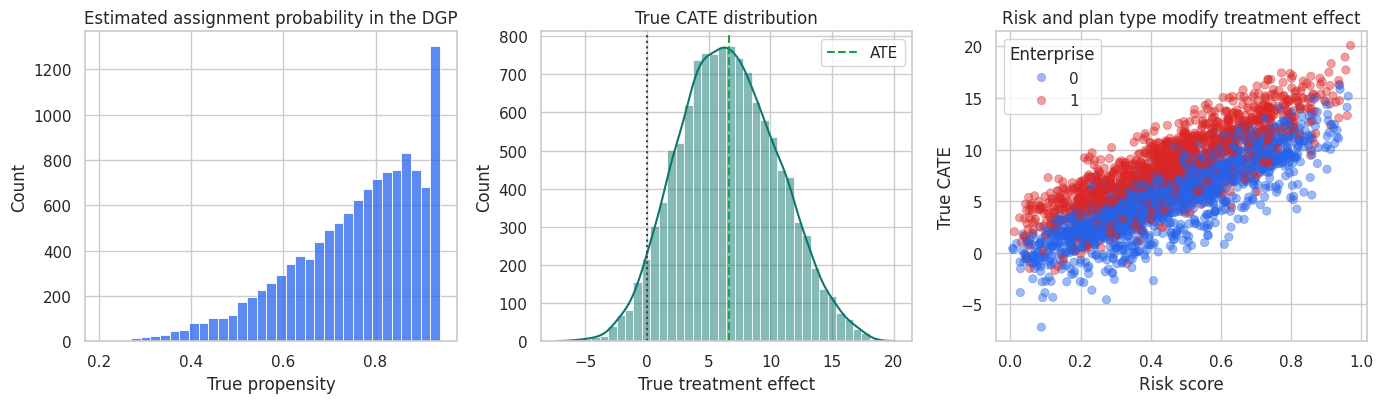

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

sns.histplot(df["propensity"], bins=35, color="#2563eb", ax=axes[0])
axes[0].set_title("Estimated assignment probability in the DGP")
axes[0].set_xlabel("True propensity")

sns.histplot(df["true_cate"], bins=40, kde=True, color="#0f766e", ax=axes[1])
axes[1].axvline(df["true_cate"].mean(), color="#16a34a", linestyle="--", label="ATE")
axes[1].axvline(0, color="#334155", linestyle=":")
axes[1].set_title("True CATE distribution")
axes[1].set_xlabel("True treatment effect")
axes[1].legend()

sample_plot = df.sample(3000, random_state=9)
sns.scatterplot(
    data=sample_plot,
    x="risk_score",
    y="true_cate",
    hue="enterprise_plan",
    alpha=0.45,
    edgecolor=None,
    palette=["#2563eb", "#dc2626"],
    ax=axes[2],
)
axes[2].set_title("Risk and plan type modify treatment effect")
axes[2].set_xlabel("Risk score")
axes[2].set_ylabel("True CATE")
axes[2].legend(title="Enterprise")

plt.tight_layout()
plt.show()

Treatment effects are heterogeneous and treatment assignment is imbalanced. This is a setting where choosing the meta-learner matters.

## 3. Train-Test Split

We will fit all nuisance functions and CATE models on the training sample, then evaluate on the test sample. In a real observational project, the test sample would not reveal the true CATE. Here the simulation ground truth lets us understand the behavior of the estimators.

In [6]:
propensity_strata = pd.qcut(df["propensity"], 5, labels=False)
train_df, test_df = train_test_split(
    df,
    test_size=0.35,
    random_state=37,
    stratify=propensity_strata,
)

split_summary = pd.DataFrame(
    {
        "sample": ["Train", "Test"],
        "n": [len(train_df), len(test_df)],
        "treatment_share": [train_df["treatment"].mean(), test_df["treatment"].mean()],
        "true_ate": [train_df["true_cate"].mean(), test_df["true_cate"].mean()],
        "mean_outcome": [train_df["outcome"].mean(), test_df["outcome"].mean()],
    }
)

display(split_summary.round(3))

,sample,n,treatment_share,true_ate,mean_outcome
0,Train,7800,0.760,6.594,84.567
1,Test,4200,0.755,6.699,85.020


## 4. S-Learner

The S-learner fits one outcome model with treatment included as a feature:

$$
\hat{\mu}(x,w) \approx E[Y \mid X=x, W=w]
$$

Then it predicts each unit twice:

$$
\hat{\tau}_S(x) = \hat{\mu}(x,1) - \hat{\mu}(x,0)
$$

This is simple and often stable because all observations are pooled into one model. The downside is that flexible supervised learners may treat the treatment indicator as a weak feature and shrink treatment heterogeneity toward zero, especially when outcome variation is much larger than treatment-effect variation.

In [7]:
s_model = reg_model(seed=101, min_samples_leaf=45)
s_features = feature_cols + ["treatment"]
s_model.fit(train_df[s_features], train_df["outcome"])

test_s0 = test_df[feature_cols].copy()
test_s1 = test_df[feature_cols].copy()
test_s0["treatment"] = 0
test_s1["treatment"] = 1

test_scored = test_df.copy()
test_scored["cate_s_learner"] = s_model.predict(test_s1[s_features]) - s_model.predict(test_s0[s_features])

pd.DataFrame(
    {
        "quantity": ["Mean S-learner CATE", "True ATE in test", "S-learner CATE std", "True CATE std"],
        "value": [
            test_scored["cate_s_learner"].mean(),
            test_scored["true_cate"].mean(),
            test_scored["cate_s_learner"].std(),
            test_scored["true_cate"].std(),
        ],
    }
).round(3)

,quantity,value
0,Mean S-learner CATE,0.367
1,True ATE in test,6.699
2,S-learner CATE std,0.619
3,True CATE std,3.961


A small estimated CATE standard deviation is a warning sign. It can mean treatment effects are actually homogeneous, but it can also mean the S-learner is not using the treatment interactions strongly enough.

## 5. T-Learner

The T-learner fits separate outcome models for treated and control units:

$$
\hat{\mu}_1(x) \approx E[Y \mid W=1, X=x]
$$

$$
\hat{\mu}_0(x) \approx E[Y \mid W=0, X=x]
$$

Then:

$$
\hat{\tau}_T(x) = \hat{\mu}_1(x) - \hat{\mu}_0(x)
$$

The T-learner can learn very different treated and control response surfaces. That is useful when treatment changes the shape of the outcome function. It can be noisy when one treatment arm is small or when the treated and control models extrapolate in different ways.

In [8]:
t_model_1 = reg_model(seed=201, min_samples_leaf=45)
t_model_0 = reg_model(seed=202, min_samples_leaf=45)

t_model_1.fit(
    train_df.loc[train_df["treatment"] == 1, feature_cols],
    train_df.loc[train_df["treatment"] == 1, "outcome"],
)
t_model_0.fit(
    train_df.loc[train_df["treatment"] == 0, feature_cols],
    train_df.loc[train_df["treatment"] == 0, "outcome"],
)

test_scored["mu1_hat_t"] = t_model_1.predict(test_scored[feature_cols])
test_scored["mu0_hat_t"] = t_model_0.predict(test_scored[feature_cols])
test_scored["cate_t_learner"] = test_scored["mu1_hat_t"] - test_scored["mu0_hat_t"]

pd.DataFrame(
    {
        "quantity": [
            "Training treated units",
            "Training control units",
            "Mean T-learner CATE",
            "T-learner CATE std",
        ],
        "value": [
            (train_df["treatment"] == 1).sum(),
            (train_df["treatment"] == 0).sum(),
            test_scored["cate_t_learner"].mean(),
            test_scored["cate_t_learner"].std(),
        ],
    }
).round(3)

,quantity,value
0,Training treated units,5929.000
1,Training control units,1871.000
2,Mean T-learner CATE,5.376
3,T-learner CATE std,5.883


The T-learner has more freedom than the S-learner, but it pays for that freedom by splitting the sample. In this example, controls are much less common than treated accounts, so the control outcome model is the fragile part.

## 6. X-Learner

The X-learner was designed to use imputed treatment effects and can work well when treatment groups are imbalanced (Kunzel et al., 2019).

First fit the T-learner outcome models. Then impute treatment effects for each observed arm:

For treated units:

$$
D_i^1 = Y_i - \hat{\mu}_0(X_i)
$$

For control units:

$$
D_i^0 = \hat{\mu}_1(X_i) - Y_i
$$

Then fit two treatment-effect models:

$$
\hat{\tau}_1(x) \approx E[D^1 \mid X=x, W=1]
$$

$$
\hat{\tau}_0(x) \approx E[D^0 \mid X=x, W=0]
$$

Finally combine them. Different implementations use different weighting conventions. Here we make the convention explicit and use a propensity-based blend:

$$
\hat{\tau}_X(x) = \hat{e}(x)\hat{\tau}_0(x) + (1-\hat{e}(x))\hat{\tau}_1(x)
$$

where $\hat{e}(x)=P(W=1 \mid X=x)$.

In [9]:
train_x = train_df.copy()
train_x["mu0_hat"] = t_model_0.predict(train_x[feature_cols])
train_x["mu1_hat"] = t_model_1.predict(train_x[feature_cols])

imputed_treated = train_x.loc[train_x["treatment"] == 1, "outcome"] - train_x.loc[
    train_x["treatment"] == 1, "mu0_hat"
]
imputed_control = train_x.loc[train_x["treatment"] == 0, "mu1_hat"] - train_x.loc[
    train_x["treatment"] == 0, "outcome"
]

tau_model_treated = reg_model(seed=301, min_samples_leaf=45)
tau_model_control = reg_model(seed=302, min_samples_leaf=45)

tau_model_treated.fit(train_x.loc[train_x["treatment"] == 1, feature_cols], imputed_treated)
tau_model_control.fit(train_x.loc[train_x["treatment"] == 0, feature_cols], imputed_control)

propensity_model = cls_model(seed=303, min_samples_leaf=45)
propensity_model.fit(train_df[feature_cols], train_df["treatment"])

test_scored["e_hat"] = np.clip(propensity_model.predict_proba(test_scored[feature_cols])[:, 1], 0.05, 0.95)
test_scored["cate_x_from_treated"] = tau_model_treated.predict(test_scored[feature_cols])
test_scored["cate_x_from_control"] = tau_model_control.predict(test_scored[feature_cols])
test_scored["cate_x_learner"] = (
    test_scored["e_hat"] * test_scored["cate_x_from_control"]
    + (1 - test_scored["e_hat"]) * test_scored["cate_x_from_treated"]
)

propensity_diagnostics = pd.DataFrame(
    {
        "quantity": [
            "Propensity AUC on training data",
            "Mean estimated propensity in test",
            "Minimum estimated propensity in test",
            "Maximum estimated propensity in test",
            "Mean X-learner CATE",
        ],
        "value": [
            roc_auc_score(train_df["treatment"], propensity_model.predict_proba(train_df[feature_cols])[:, 1]),
            test_scored["e_hat"].mean(),
            test_scored["e_hat"].min(),
            test_scored["e_hat"].max(),
            test_scored["cate_x_learner"].mean(),
        ],
    }
)

display(propensity_diagnostics.round(3))

,quantity,value
0,Propensity AUC on training data,0.777
1,Mean estimated propensity in test,0.760
2,Minimum estimated propensity in test,0.368
3,Maximum estimated propensity in test,0.950
4,Mean X-learner CATE,5.758


The propensity model is not just a prediction convenience. It tells the X-learner how treatment assignment changes across feature profiles and helps combine information from the two imputed-effect models.

## 7. R-Learner

The R-learner is based on residualizing both outcome and treatment assignment. Let:

$$
 m(x)=E[Y \mid X=x]
$$

$$
 e(x)=E[W \mid X=x]
$$

The partially linear representation is:

$$
Y - m(X) = (W-e(X))\tau(X) + \epsilon
$$

The R-learner estimates $m(x)$ and $e(x)$ first, then fits $\tau(x)$ by minimizing:

$$
\sum_i \left((Y_i-\hat{m}(X_i)) - (W_i-\hat{e}(X_i))\tau(X_i)\right)^2
$$

A convenient implementation regresses:

$$
\frac{Y_i-\hat{m}(X_i)}{W_i-\hat{e}(X_i)}
$$

on $X_i$ with weights $(W_i-\hat{e}(X_i))^2$. Cross-fitting is used so the residuals are not evaluated on the same observations used to train the nuisance models. Nie and Wager (2020) show why this residualized objective can have favorable properties for CATE estimation.

In [10]:
def fit_r_learner(train, test, features, n_splits=3):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=411)
    m_hat = np.zeros(len(train))
    e_hat = np.zeros(len(train))

    for fold_id, (fit_idx, pred_idx) in enumerate(kfold.split(train), start=1):
        fit_data = train.iloc[fit_idx]
        pred_data = train.iloc[pred_idx]

        outcome_model = reg_model(seed=410 + fold_id, min_samples_leaf=60)
        treatment_model = cls_model(seed=420 + fold_id, min_samples_leaf=60)

        outcome_model.fit(fit_data[features], fit_data["outcome"])
        treatment_model.fit(fit_data[features], fit_data["treatment"])

        m_hat[pred_idx] = outcome_model.predict(pred_data[features])
        e_hat[pred_idx] = treatment_model.predict_proba(pred_data[features])[:, 1]

    e_hat = np.clip(e_hat, 0.05, 0.95)
    y_residual = train["outcome"].to_numpy() - m_hat
    w_residual = train["treatment"].to_numpy() - e_hat
    keep = np.abs(w_residual) > 0.03

    r_target = y_residual[keep] / w_residual[keep]
    r_weight = w_residual[keep] ** 2

    tau_model = reg_model(seed=450, min_samples_leaf=45)
    tau_model.fit(train.iloc[keep][features], r_target, sample_weight=r_weight)

    return tau_model.predict(test[features]), pd.DataFrame(
        {
            "m_hat": m_hat,
            "e_hat": e_hat,
            "y_residual": y_residual,
            "w_residual": w_residual,
            "kept_for_tau_stage": keep,
        },
        index=train.index,
    )


test_scored["cate_r_learner"], r_diagnostics = fit_r_learner(train_df, test_scored, feature_cols)

display(
    pd.DataFrame(
        {
            "quantity": [
                "Mean out-of-fold e_hat",
                "Std of treatment residual",
                "Share kept for tau stage",
                "Mean R-learner CATE in test",
            ],
            "value": [
                r_diagnostics["e_hat"].mean(),
                r_diagnostics["w_residual"].std(),
                r_diagnostics["kept_for_tau_stage"].mean(),
                test_scored["cate_r_learner"].mean(),
            ],
        }
    ).round(3)
)

,quantity,value
0,Mean out-of-fold e_hat,0.760
1,Std of treatment residual,0.407
2,Share kept for tau stage,1.000
3,Mean R-learner CATE in test,5.782


The R-learner focuses on variation in treatment assignment that remains after accounting for $X$. If overlap is weak and $W-\hat{e}(X)$ is often near zero, the residualized problem becomes noisy. That is why overlap diagnostics are not optional.

## 8. DR-Learner

The DR-learner uses a doubly robust pseudo-outcome. First estimate $\mu_0(x)$, $\mu_1(x)$, and $e(x)$. Then construct:

$$
\phi_i = \hat{\mu}_1(X_i) - \hat{\mu}_0(X_i) + \frac{W_i(Y_i-\hat{\mu}_1(X_i))}{\hat{e}(X_i)} - \frac{(1-W_i)(Y_i-\hat{\mu}_0(X_i))}{1-\hat{e}(X_i)}
$$

Under the usual assumptions, this pseudo-outcome behaves like a noisy version of the treatment effect. The final step regresses $\phi_i$ on $X_i$:

$$
\hat{\tau}_{DR}(x) \approx E[\phi \mid X=x]
$$

Kennedy (2023) studies doubly robust estimation of heterogeneous causal effects and emphasizes that pseudo-outcome approaches can reduce sensitivity to nuisance estimation errors when constructed carefully.

In [11]:
def fit_dr_learner(train, test, features, n_splits=3):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=511)
    mu0_hat = np.zeros(len(train))
    mu1_hat = np.zeros(len(train))
    e_hat = np.zeros(len(train))

    for fold_id, (fit_idx, pred_idx) in enumerate(kfold.split(train), start=1):
        fit_data = train.iloc[fit_idx]
        pred_data = train.iloc[pred_idx]

        mu0_model = reg_model(seed=510 + fold_id, min_samples_leaf=55)
        mu1_model = reg_model(seed=520 + fold_id, min_samples_leaf=55)
        e_model = cls_model(seed=530 + fold_id, min_samples_leaf=55)

        mu0_model.fit(
            fit_data.loc[fit_data["treatment"] == 0, features],
            fit_data.loc[fit_data["treatment"] == 0, "outcome"],
        )
        mu1_model.fit(
            fit_data.loc[fit_data["treatment"] == 1, features],
            fit_data.loc[fit_data["treatment"] == 1, "outcome"],
        )
        e_model.fit(fit_data[features], fit_data["treatment"])

        mu0_hat[pred_idx] = mu0_model.predict(pred_data[features])
        mu1_hat[pred_idx] = mu1_model.predict(pred_data[features])
        e_hat[pred_idx] = e_model.predict_proba(pred_data[features])[:, 1]

    e_hat = np.clip(e_hat, 0.05, 0.95)
    treatment = train["treatment"].to_numpy()
    outcome = train["outcome"].to_numpy()

    phi = (
        mu1_hat
        - mu0_hat
        + treatment * (outcome - mu1_hat) / e_hat
        - (1 - treatment) * (outcome - mu0_hat) / (1 - e_hat)
    )

    tau_model = reg_model(seed=560, min_samples_leaf=50)
    tau_model.fit(train[features], phi)

    # Holdout pseudo-outcome for bucket validation. These nuisance models are trained on train only.
    mu0_full = reg_model(seed=561, min_samples_leaf=55)
    mu1_full = reg_model(seed=562, min_samples_leaf=55)
    e_full = cls_model(seed=563, min_samples_leaf=55)

    mu0_full.fit(train.loc[train["treatment"] == 0, features], train.loc[train["treatment"] == 0, "outcome"])
    mu1_full.fit(train.loc[train["treatment"] == 1, features], train.loc[train["treatment"] == 1, "outcome"])
    e_full.fit(train[features], train["treatment"])

    test_mu0 = mu0_full.predict(test[features])
    test_mu1 = mu1_full.predict(test[features])
    test_e = np.clip(e_full.predict_proba(test[features])[:, 1], 0.05, 0.95)
    test_w = test["treatment"].to_numpy()
    test_y = test["outcome"].to_numpy()
    test_phi = test_mu1 - test_mu0 + test_w * (test_y - test_mu1) / test_e - (1 - test_w) * (test_y - test_mu0) / (1 - test_e)

    diagnostics = pd.DataFrame(
        {
            "mu0_hat": mu0_hat,
            "mu1_hat": mu1_hat,
            "e_hat": e_hat,
            "phi": phi,
        },
        index=train.index,
    )

    return tau_model.predict(test[features]), test_phi, diagnostics


test_scored["cate_dr_learner"], test_scored["dr_pseudo_outcome"], dr_diagnostics = fit_dr_learner(
    train_df,
    test_scored,
    feature_cols,
)

display(
    pd.DataFrame(
        {
            "quantity": [
                "Mean DR pseudo-outcome in train",
                "Mean true CATE in train",
                "Std DR pseudo-outcome in train",
                "Mean DR-learner CATE in test",
            ],
            "value": [
                dr_diagnostics["phi"].mean(),
                train_df["true_cate"].mean(),
                dr_diagnostics["phi"].std(),
                test_scored["cate_dr_learner"].mean(),
            ],
        }
    ).round(3)
)

,quantity,value
0,Mean DR pseudo-outcome in train,5.836
1,Mean true CATE in train,6.594
2,Std DR pseudo-outcome in train,24.968
3,Mean DR-learner CATE in test,5.868


The DR pseudo-outcome is intentionally noisy. Its value is not that every row is accurate. Its value is that averaging or smoothing it over comparable feature profiles can recover treatment-effect structure.

## 9. Comparing the Meta-Learners

In a simulation, we can compare estimated CATEs to the true CATE. In real work, we would rely on holdout experiments, policy value, calibration by score bucket, and sensitivity checks.

In [12]:
score_columns = {
    "S-learner": "cate_s_learner",
    "T-learner": "cate_t_learner",
    "X-learner": "cate_x_learner",
    "R-learner": "cate_r_learner",
    "DR-learner": "cate_dr_learner",
}

metrics_table = pd.DataFrame(
    [
        cate_metrics(test_scored, score_col, label, contact_fraction=0.20, margin=1.0, contact_cost=0.0)
        for label, score_col in score_columns.items()
    ]
).sort_values("cate_rmse")

display(metrics_table.round(3))

,learner,cate_rmse,cate_correlation,mean_predicted_cate,true_ate_in_test,true_cate_top20,share_negative_top20,net_value_per_account_top20
2,X-learner,1.930,0.906,5.758,6.699,11.915,0.000,2.383
4,DR-learner,2.946,0.766,5.868,6.699,10.778,0.005,2.156
3,R-learner,3.040,0.761,5.782,6.699,10.834,0.000,2.167
1,T-learner,5.448,0.480,5.376,6.699,9.537,0.006,1.907
0,S-learner,7.455,0.121,0.367,6.699,7.357,0.013,1.471


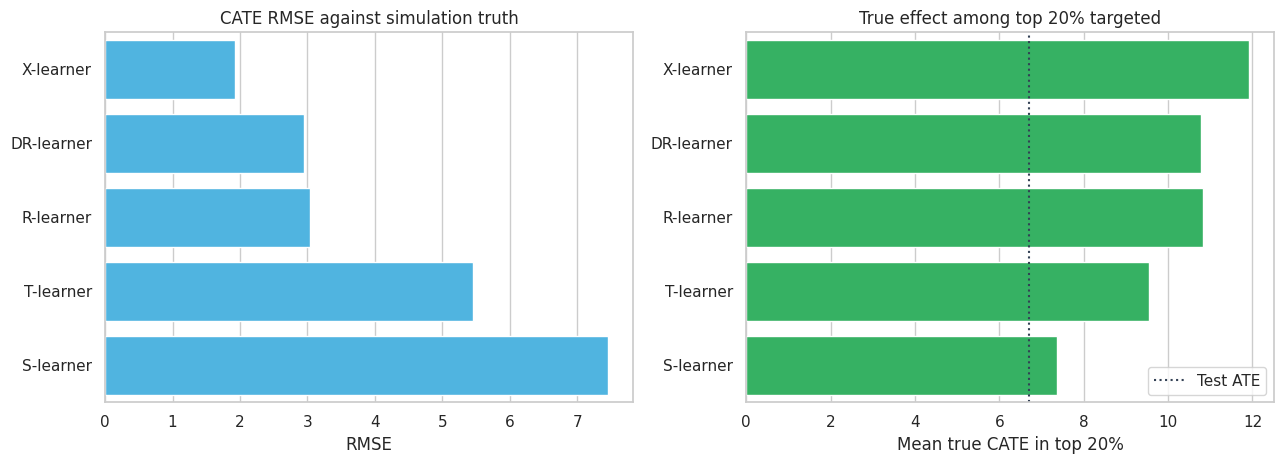

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=metrics_table, y="learner", x="cate_rmse", color="#38bdf8", ax=axes[0])
axes[0].set_title("CATE RMSE against simulation truth")
axes[0].set_xlabel("RMSE")
axes[0].set_ylabel("")

sns.barplot(data=metrics_table, y="learner", x="true_cate_top20", color="#22c55e", ax=axes[1])
axes[1].axvline(test_scored["true_cate"].mean(), color="#334155", linestyle=":", label="Test ATE")
axes[1].set_title("True effect among top 20% targeted")
axes[1].set_xlabel("Mean true CATE in top 20%")
axes[1].set_ylabel("")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

The S-learner underestimates heterogeneity in this setting. The X-learner performs well because treatment is imbalanced and the imputed-effect strategy uses information from both outcome surfaces. R- and DR-learners also recover meaningful rankings, but their pseudo-outcomes are noisy and depend on nuisance quality.

The point is not that one learner always wins. Kunzel et al. (2019) emphasize that different meta-learners can be best in different data-generating settings. The right practical stance is to compare several credible learners and understand why they disagree.

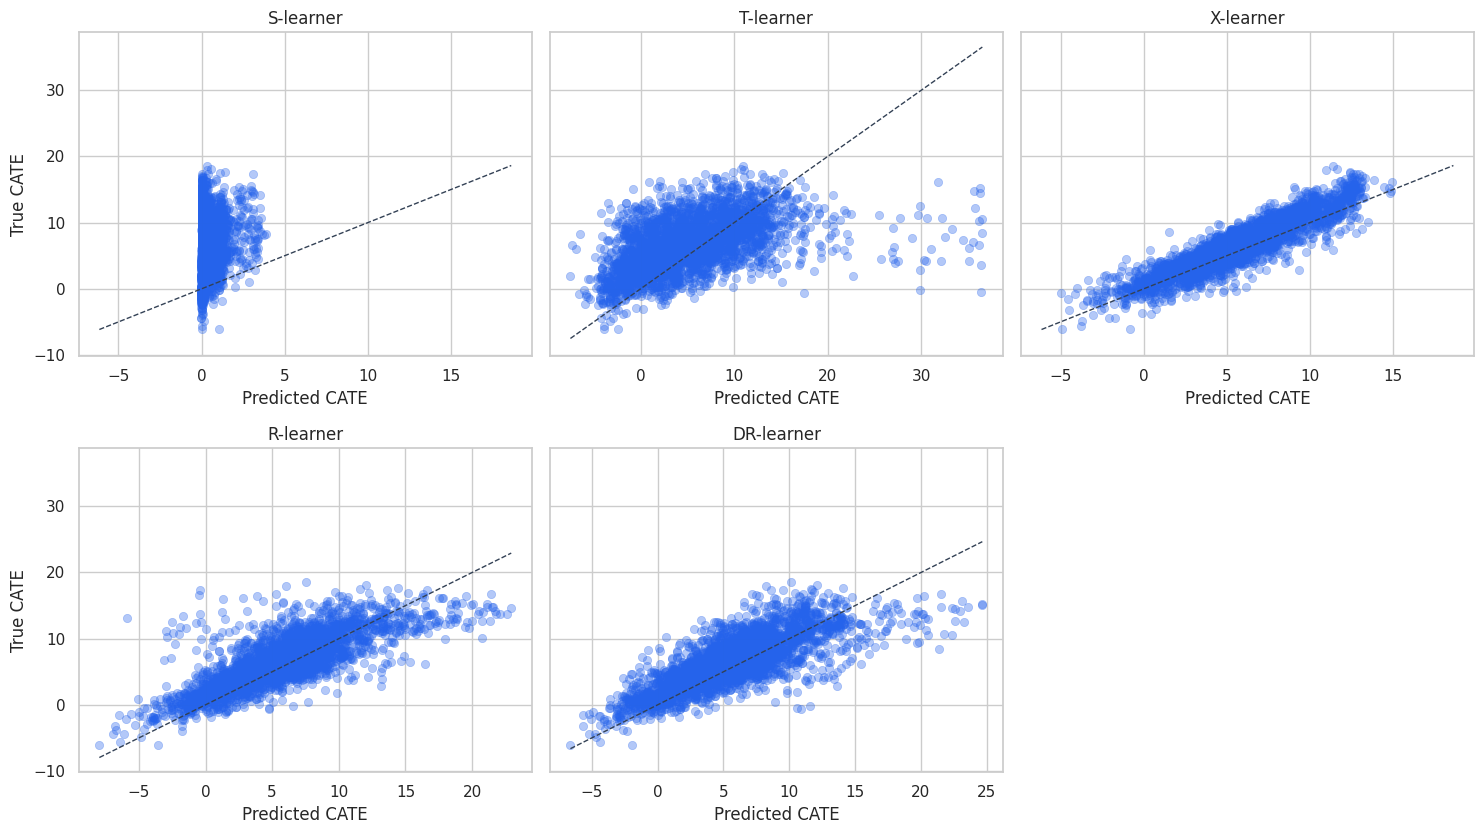

In [14]:
plot_sample = test_scored.sample(3000, random_state=88)
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5), sharey=True)
axes = axes.flatten()

for ax, (label, score_col) in zip(axes, score_columns.items()):
    sns.scatterplot(
        data=plot_sample,
        x=score_col,
        y="true_cate",
        alpha=0.35,
        edgecolor=None,
        color="#2563eb",
        ax=ax,
    )
    line_min = min(plot_sample[score_col].min(), plot_sample["true_cate"].min())
    line_max = max(plot_sample[score_col].max(), plot_sample["true_cate"].max())
    ax.plot([line_min, line_max], [line_min, line_max], color="#334155", linestyle="--", linewidth=1)
    ax.set_title(label)
    ax.set_xlabel("Predicted CATE")
    ax.set_ylabel("True CATE")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

The scatter plots show calibration and spread. A model can rank well but be poorly calibrated in level. For targeting, ranking may be enough. For financial planning, calibration matters because it feeds expected value estimates.

## 10. Bucket-Level Validation

Individual treatment effects are not observed in real data. A practical check is to sort accounts by predicted CATE and estimate average effects by bucket.

Because this is observational data, a naive treated-control gap within a bucket can still be biased. The DR pseudo-outcome gives an adjusted bucket-level diagnostic. In a real project, the strongest validation would be a randomized holdout or randomized exploration traffic.

,decile,n,treatment_share,naive_gap,true_cate_mean,predicted_cate_mean,dr_pseudo_outcome_mean
0,D1 highest,420,0.874,9.181,12.888,11.679,13.603
1,D2,420,0.883,5.012,10.942,9.429,7.488
2,D3,420,0.864,9.571,9.292,8.143,11.450
3,D4,420,0.824,7.190,8.141,7.164,9.531
4,D5,420,0.781,5.318,6.890,6.087,6.637
5,D6,420,0.717,2.695,6.188,5.205,6.934
6,D7,420,0.745,0.293,5.057,4.419,3.733
7,D8,420,0.662,2.495,4.077,3.505,2.847
8,D9,420,0.667,1.020,2.835,2.193,1.852
9,D10,420,0.538,-3.459,0.681,-0.243,-1.135


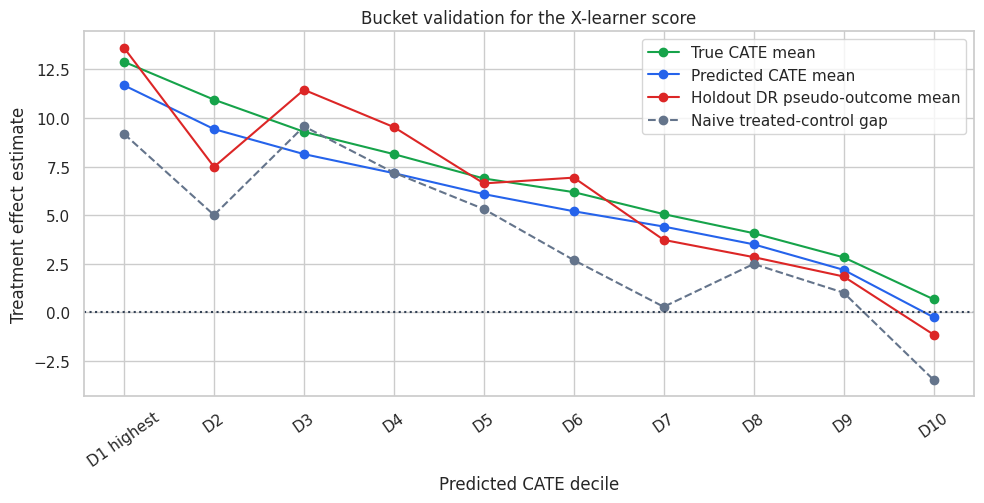

In [15]:
bucket_table = decile_summary(
    test_scored,
    score_col="cate_x_learner",
    dr_score_col="dr_pseudo_outcome",
)

display(bucket_table.round(3))

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(
    bucket_table["decile"],
    bucket_table["true_cate_mean"],
    marker="o",
    label="True CATE mean",
    color="#16a34a",
)
ax.plot(
    bucket_table["decile"],
    bucket_table["predicted_cate_mean"],
    marker="o",
    label="Predicted CATE mean",
    color="#2563eb",
)
ax.plot(
    bucket_table["decile"],
    bucket_table["dr_pseudo_outcome_mean"],
    marker="o",
    label="Holdout DR pseudo-outcome mean",
    color="#dc2626",
)
ax.plot(
    bucket_table["decile"],
    bucket_table["naive_gap"],
    marker="o",
    label="Naive treated-control gap",
    color="#64748b",
    linestyle="--",
)
ax.axhline(0, color="#334155", linestyle=":")
ax.set_title("Bucket validation for the X-learner score")
ax.set_xlabel("Predicted CATE decile")
ax.set_ylabel("Treatment effect estimate")
ax.tick_params(axis="x", rotation=35)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

The bucket plot is the kind of diagnostic that usually resonates with stakeholders. The top predicted-CATE buckets should have higher adjusted effect estimates than the lower buckets. If the naive gap diverges from the adjusted diagnostic, that is a reminder that treatment assignment was not random.

## 11. Policy Curves

Meta-learners are often used to allocate scarce treatment capacity. We can ask: if we contact the top $k$ percent of accounts by each learner's score, what true incremental value do we get in the simulation?

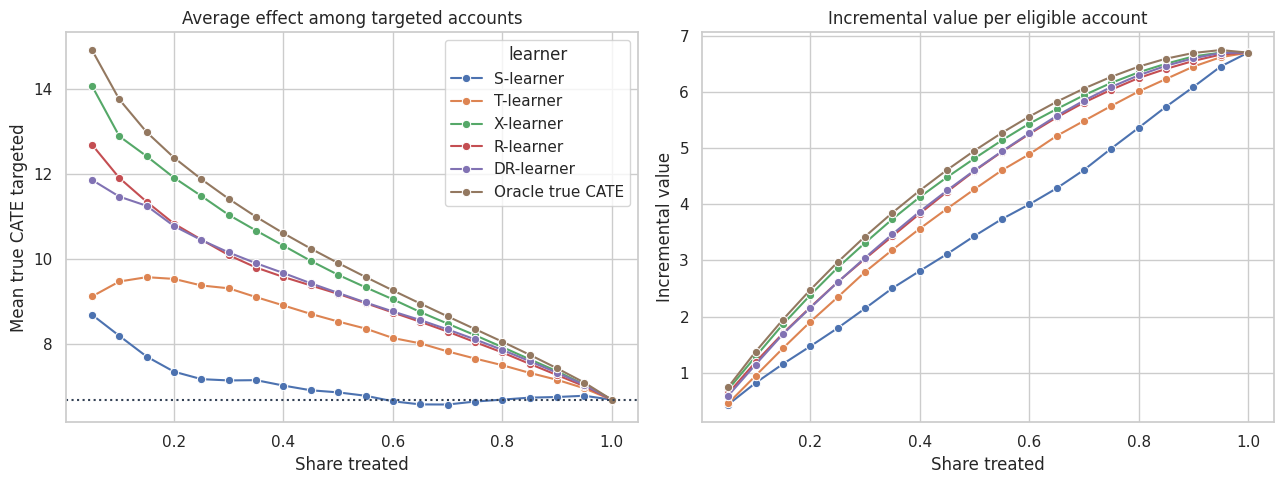

In [16]:
fractions = np.linspace(0.05, 1.00, 20)
curve_rows = []

for label, score_col in score_columns.items():
    for fraction in fractions:
        selected = top_fraction_mask(test_scored, score_col, fraction=fraction)
        targeted = test_scored.loc[selected]
        curve_rows.append(
            {
                "learner": label,
                "contact_share": fraction,
                "mean_true_cate_targeted": targeted["true_cate"].mean(),
                "incremental_value_per_account": fraction * targeted["true_cate"].mean(),
                "share_negative_targeted": (targeted["true_cate"] < 0).mean(),
            }
        )

selected = None
for fraction in fractions:
    oracle_selected = top_fraction_mask(test_scored, "true_cate", fraction=fraction)
    targeted = test_scored.loc[oracle_selected]
    curve_rows.append(
        {
            "learner": "Oracle true CATE",
            "contact_share": fraction,
            "mean_true_cate_targeted": targeted["true_cate"].mean(),
            "incremental_value_per_account": fraction * targeted["true_cate"].mean(),
            "share_negative_targeted": (targeted["true_cate"] < 0).mean(),
        }
    )

policy_curves = pd.DataFrame(curve_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(
    data=policy_curves,
    x="contact_share",
    y="mean_true_cate_targeted",
    hue="learner",
    marker="o",
    ax=axes[0],
)
axes[0].axhline(test_scored["true_cate"].mean(), color="#334155", linestyle=":")
axes[0].set_title("Average effect among targeted accounts")
axes[0].set_xlabel("Share treated")
axes[0].set_ylabel("Mean true CATE targeted")

sns.lineplot(
    data=policy_curves,
    x="contact_share",
    y="incremental_value_per_account",
    hue="learner",
    marker="o",
    ax=axes[1],
)
axes[1].set_title("Incremental value per eligible account")
axes[1].set_xlabel("Share treated")
axes[1].set_ylabel("Incremental value")
axes[1].legend_.remove()

plt.tight_layout()
plt.show()

Policy curves are often more useful than one global metric. If the business can treat only 10% of accounts, we care most about the left side of the curve. If the business can treat 70%, calibration over a much broader range matters.

## 12. How to Choose a Meta-Learner in Practice

A practical starting guide:

- S-learner: good baseline when treatment effects are expected to be small, sparse, or close to constant; watch for shrinkage toward zero.
- T-learner: useful when treated and control outcome surfaces may differ substantially; watch for sample splitting and weak overlap.
- X-learner: attractive when treatment arms are imbalanced and outcome models are reasonably accurate.
- R-learner: useful when you want an orthogonal residualized objective and a tunable CATE regression problem.
- DR-learner: useful when you want a pseudo-outcome with doubly robust structure; nuisance quality and cross-fitting matter.

In serious applied work, do not select a learner only because it gives the most exciting heterogeneity. Compare stability, bucket-level validation, policy value, and sensitivity to nuisance models.

## 13. Industry Workflow

A credible meta-learner project usually follows this pattern:

1. Define the treatment, outcome, horizon, unit, and eligible population.
2. Restrict to pre-treatment features.
3. Diagnose overlap and treatment assignment mechanisms.
4. Fit several meta-learners with cross-fitting where nuisance models are used.
5. Compare rankings by bucket-level adjusted effect estimates.
6. Translate scores into a treatment policy under capacity and cost constraints.
7. Keep a randomized holdout or exploration policy for future validation.
8. Monitor model drift, subgroup harm, and treatment saturation.

The model is only one part of the system. The experiment or logging design that validates the model is just as important.

In [17]:
workflow_table = pd.DataFrame(
    {
        "decision": [
            "First benchmark",
            "Most useful in this simulation",
            "Main risk",
            "Validation priority",
            "Deployment advice",
        ],
        "recommendation": [
            "Fit S-, T-, X-, R-, and DR-style baselines with the same feature set.",
            "The X-learner ranks well because treatment is imbalanced and outcome models are informative.",
            "Unobserved confounding would invalidate all observational estimates.",
            "Use randomized holdout traffic and bucket-level lift by predicted CATE.",
            "Treat scores as policy inputs, not as literal individual-level truths.",
        ],
    }
)

display(workflow_table)

,decision,recommendation
0,First benchmark,"Fit S-, T-, X-, R-, and DR-style baselines wit..."
1,Most useful in this simulation,The X-learner ranks well because treatment is ...
2,Main risk,Unobserved confounding would invalidate all ob...
3,Validation priority,Use randomized holdout traffic and bucket-leve...
4,Deployment advice,"Treat scores as policy inputs, not as literal ..."


## Key Takeaways

- Meta-learners are recipes that combine supervised learning with causal structure.
- The S-learner pools treated and control units but can shrink treatment heterogeneity.
- The T-learner estimates treated and control outcome surfaces separately but can be noisy when one arm is small.
- The X-learner uses imputed effects and is often useful with imbalanced treatment arms.
- The R-learner residualizes outcome and treatment, then learns CATE from the residualized relationship.
- The DR-learner builds a doubly robust pseudo-outcome and regresses it on features.
- No learner is universally best; compare several learners with diagnostics connected to the business decision.

## References

Curth, A., & van der Schaar, M. (2021). Nonparametric estimation of heterogeneous treatment effects: From theory to learning algorithms. *arXiv*. https://doi.org/10.48550/arXiv.2101.10943

Kennedy, E. H. (2023). Towards optimal doubly robust estimation of heterogeneous causal effects. *Electronic Journal of Statistics, 17*(2). https://doi.org/10.1214/23-EJS2157

Kunzel, S. R., Sekhon, J. S., Bickel, P. J., & Yu, B. (2019). Metalearners for estimating heterogeneous treatment effects using machine learning. *Proceedings of the National Academy of Sciences, 116*(10), 4156-4165. https://doi.org/10.1073/pnas.1804597116

Nie, X., & Wager, S. (2020). Quasi-oracle estimation of heterogeneous treatment effects. *Biometrika, 108*(2), 299-319. https://doi.org/10.1093/biomet/asaa076

Powers, S., Qian, J., Jung, K., Schuler, A., Shah, N. H., Hastie, T., & Tibshirani, R. (2018). Some methods for heterogeneous treatment effect estimation in high dimensions. *Statistics in Medicine, 37*(11), 1767-1787. https://doi.org/10.1002/sim.7623